# Conditionals: Session 1: Booleans and if / else / elif

**Objectives:** By the end of this session you will be able to:
- Explain what a Boolean value is and how Python uses it to make decisions
- Write `if`, `if/else`, and `if/elif/else` statements
- Draw a flowchart to plan conditional logic before writing code
- Combine a `for` loop with an `if` statement to process a list of values

## What is a Boolean?

Before we can write a conditional, we need to understand what Python is actually checking.

A **Boolean** is a value that is either `True` or `False`, nothing else. Named after mathematician George Boole, it is the simplest data type in Python.

```python
True   # capital T
False  # capital F
```

Any comparison you write in Python evaluates to one of these two values. That result is what the `if` statement acts on.

In [ ]:
# Booleans are a data type just like int or str
print(type(True))

In [ ]:
print(type(False))

In [ ]:
# A comparison produces a Boolean
print(10 > 5)    # True

In [ ]:
print(10 < 5)    # False

In [ ]:
print(10 == 10)  # True; note: == not =

In [ ]:
print(10 != 10)  # False

## Comparison Operators

| Operator | Meaning | Example | Result |
|---|---|---|---|
| `>` | greater than | `5 > 3` | `True` |
| `<` | less than | `5 < 3` | `False` |
| `>=` | greater than or equal | `5 >= 5` | `True` |
| `<=` | less than or equal | `4 <= 5` | `True` |
| `==` | equal to | `5 == 5` | `True` |
| `!=` | not equal to | `5 != 3` | `True` |

> **Common mistake:** `=` assigns a value. `==` compares two values. These are not the same!

In [ ]:
# Try a few yourself
print(3.14 >= 3)

In [ ]:
print("hello" == "Hello")   # case-sensitive!

In [ ]:
print(100 != 99)

## The `if` Statement

An `if` statement runs a block of code only when a condition is `True`.

```python
if condition:
    # this runs only if condition is True
```

The indented block is called the **body**. Python uses indentation (4 spaces or 1 tab) to know what belongs inside the `if`.

### ✏️ Flowchart exercise (draw on paper before coding)

Draw a diamond for the decision and two branches (True / False) for this scenario:

> You tested a concrete cylinder. The compressive stress is 4 350 psi.  
> The design limit is 4 000 psi.  
> Is the specimen a PASS or a FAIL?

<details>
<summary><b>Show flowchart</b> (draw yours first)</summary>

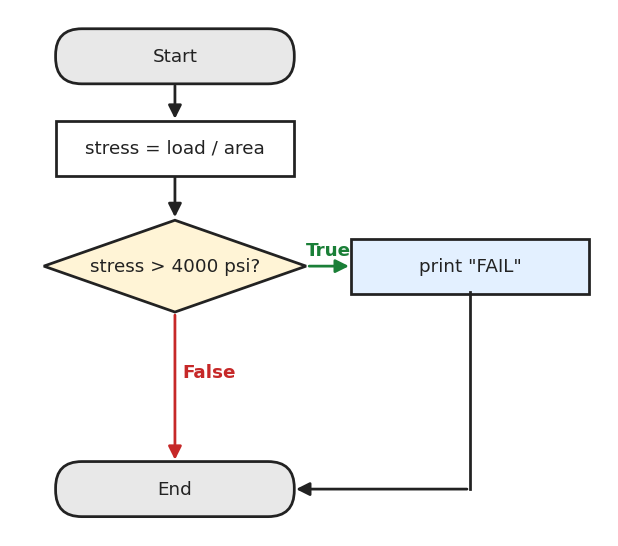 4000 psi?'. True goes to print FAIL, False goes to End." width="460">

</details>

In [ ]:
# Concrete compression test; callback to Session 1 of intro Python
load = 123000   # lbs applied to the cylinder
area = 28.27  # sq in (6-inch diameter cylinder)
stress = load / area  # psi
print(f"Stress: {stress:.1f} psi")

In [ ]:
design_limit = 4000   # psi design compressive strength

if stress > design_limit:
    print(f"FAIL: stress is {stress:.1f} psi, exceeds limit of {design_limit} psi")

What happens when `stress` is below the limit? Right now the code is silent. Try changing `load` to 85 000 and running both cells again. The stress prints, but the `if` cell prints nothing, because we haven't told Python what to do in the `False` case.

In [ ]:
# Your Turn #1: change load so the specimen passes, then change it so it fails
# Recalculate stress and print it, then use an if statement to print a FAIL message when stress exceeds design_limit
load = 85000   # try different values


## The `if / else` Statement

Add an `else` branch to handle the `False` case:

```python
if condition:
    # runs when True
else:
    # runs when False
```

### ✏️ Flowchart exercise

Extend your earlier flowchart: add the False branch that prints "PASS".

<details>
<summary><b>Show flowchart</b> (draw yours first)</summary>

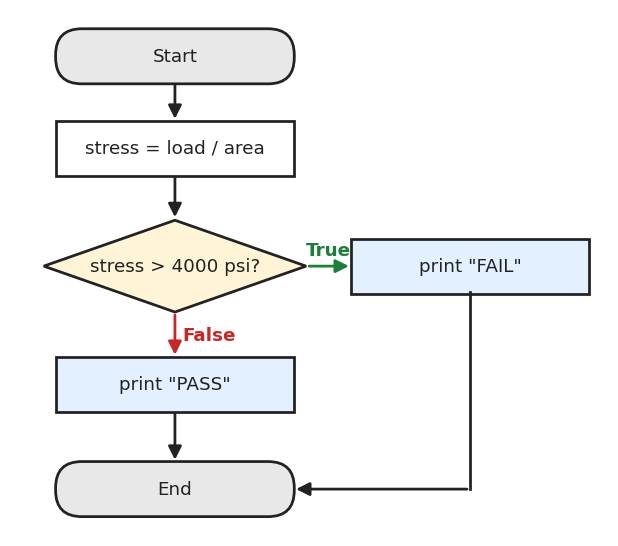

</details>

In [ ]:
# lets code together
# add an else branch that prints a PASS message when stress is within design_limit
load = 123000
stress = load / area


## The `if / elif / else` Statement

Sometimes you have **more than two outcomes**. Use `elif` (short for "else if") to chain additional conditions:

```python
if condition1:
    # runs if condition1 is True
elif condition2:
    # runs if condition1 is False AND condition2 is True
else:
    # runs if all conditions above are False
```

Python checks each condition **in order** and stops at the first one that is `True`.

### ✏️ Flowchart exercise

Draw a flowchart for three stress categories:
- **Low** (< 2 000 psi), well within limit
- **Moderate** (2 000–4 000 psi), acceptable, monitor
- **High** (> 4 000 psi), exceeds design limit

<details>
<summary><b>Show flowchart</b> (draw yours first)</summary>

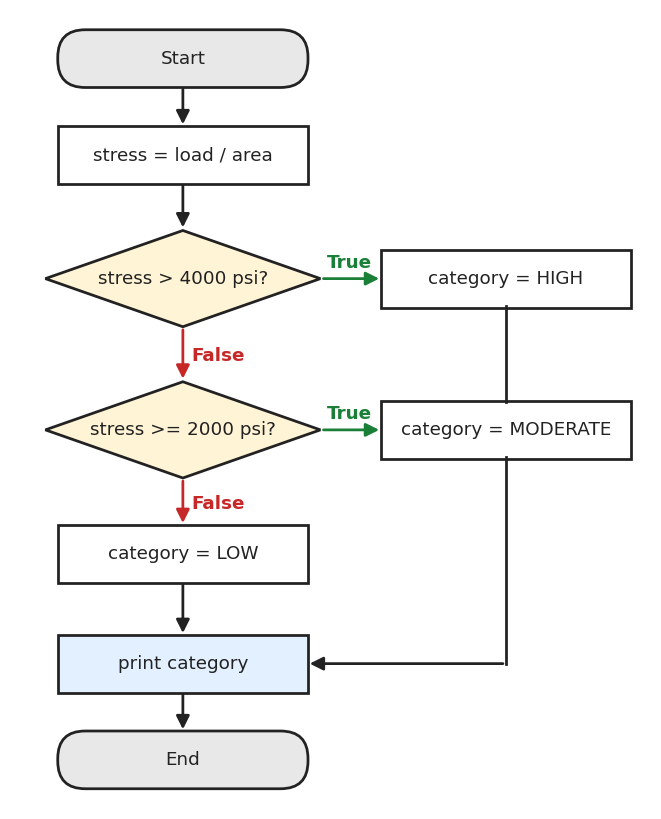 4000?' True gives HIGH; False goes to diamond 'stress >= 2000?' True gives MODERATE, False gives LOW; all go to print category, then End." width="460">

</details>

In [ ]:
load = 90000
stress = load / area
print(f"Stress: {stress:.1f} psi")

In [ ]:
if stress > 4000:
    category = "HIGH: exceeds design limit"
elif stress >= 2000:
    category = "MODERATE: acceptable, monitor"
else:
    category = "LOW: well within limit"

print(f"Stress: {stress:.1f} psi → {category}")

**Your Turn #2:** test all three categories. Loop over the loads `[50000, 90000, 127000]`, calculate the stress for each one, and print which category it falls in.

In [ ]:
# Your Turn #2
# Test all three categories


## Combining a for loop with if/elif/else: Indoor Air Quality

Now let's apply this pattern to a real dataset. You are monitoring radon levels in a building.

EPA thresholds:
- **Good:** < 2 pCi/L
- **Fair:** 2–4 pCi/L  
- **Poor:** > 4 pCi/L, action required

First, let's load the data.

In [ ]:
import pandas as pd
import requests

url = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/EZgpsrR5Q61CrlL0XqOmW80BnRAIYy0xJmS4X1B14sVMjg?e=E8xR91'
r = requests.get(url + '&download=1')
with open('radon.csv', 'w') as f:
    f.write(r.text)
print(r.status_code)   # 200 means the download worked

In [ ]:
iaq_df = pd.read_csv('radon.csv')
print(iaq_df.head())

Now categorize each reading using `if/elif/else` inside a `for` loop. Start with just the first 25 readings so you can check each label against the data:

In [ ]:
first_rows = iaq_df.head(25)
print(first_rows)

In [ ]:
# lets code together
good_threshold = 2    # pCi/L
fair_threshold = 4    # pCi/L

# loop over each reading in first_rows['Radon Hourly Reading']
# use if/elif/else to set status to "POOR: action required", "FAIR", or "GOOD"
# print the reading and its status


## In-Class Assignment

Using the radon DataFrame above, write code that:
1. Counts how many readings fall into each category (Good / Fair / Poor)
2. Prints a summary like: `Good: 12  Fair: 5  Poor: 3`

**Tip:** Create three counter variables set to 0 before the loop, then add 1 inside each branch.

**Submission:** Take a screengrab of your code and output and submit to Canvas.

In [ ]:
# your code here


## Extra Practice (optional)

These are **not graded** and you don't submit them. They are extra reps if you finish early or want more practice after class. Try each one yourself before you open the answer.

### Extra Practice #1: a stronger mix

A high-strength concrete mix has a design limit of **5 000 psi**. Use the same cylinder `area`. For each load in `[120000, 150000]`, calculate the stress and print PASS or FAIL.

In [ ]:
# Extra Practice #1


<details>
<summary><b>Show answer</b></summary>

```python
high_strength_limit = 5000   # psi

for load in [120000, 150000]:
    stress = load / area
    if stress > high_strength_limit:
        print(f"Load {load} lbs: FAIL, {stress:.1f} psi")
    else:
        print(f"Load {load} lbs: PASS, {stress:.1f} psi")

# Load 120000 lbs: PASS, 4244.8 psi
# Load 150000 lbs: FAIL, 5306.0 psi
```

</details>

### Extra Practice #2: the highest radon reading

Use a `for` loop and an `if` statement (no `.max()`) to find the highest radon reading.

**Hint:** start a variable at 0 before the loop. Inside the loop, if the reading is bigger than what you've saved so far, save the new reading.

In [ ]:
# Extra Practice #2


<details>
<summary><b>Show answer</b></summary>

```python
highest = 0

for reading in iaq_df['Radon Hourly Reading']:
    if reading > highest:
        highest = reading
        print(f"New highest so far: {highest} pCi/L")

print(f"Highest reading: {highest} pCi/L")

# Prints a line each time a bigger reading shows up. The last one is the answer:
# Highest reading: 4.9 pCi/L
```

</details>

### Extra Practice #3: save the status as a new column

Instead of printing each status, save it. Make an empty list, loop over the readings, and `append` "GOOD", "FAIR", or "POOR" for each one. Then add the list to `iaq_df` as a new column called `Status` and print only the POOR rows.

In [ ]:
# Extra Practice #3


<details>
<summary><b>Show answer</b></summary>

```python
statuses = []

for reading in iaq_df['Radon Hourly Reading']:
    if reading > 4:
        statuses.append("POOR")
    elif reading >= 2:
        statuses.append("FAIR")
    else:
        statuses.append("GOOD")

print(len(statuses))   # one status per reading: 2157

iaq_df['Status'] = statuses
print(iaq_df.head())

poor_df = iaq_df[iaq_df['Status'] == 'POOR']
print(poor_df)

# 13 rows, which matches the Poor count from the in-class assignment
```

</details>